# Synthetic Experiment

## Parameters Settings

In [118]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skewnorm
from itertools import combinations

SEED = 20260504
RNG = np.random.default_rng(SEED)

NUM_STATES   = 100
NUM_ACTIONS  = 5
NUM_PATIENTS = 1000

SIGMA_LOW  = 20
SIGMA_HIGH = 50

NUM_SOURCES = 4
BASE_BIAS = 2
BASE_VAR  = 6
BASE_COST = 10.0

BIAS_MULTIPLIERS = np.array([1, 1, 2.5, 2.5])
VAR_MULTIPLIERS  = np.array([1, 8, 0.5, 8])
COST_MULTIPLIERS = np.array([2, 0.5, 1, 0.1])
COSTS  = BASE_COST * COST_MULTIPLIERS
BUDGET = NUM_PATIENTS * BASE_COST

FLIP_PROB = 0.1

print(f"Synthetic Setup: S={NUM_STATES}, A={NUM_ACTIONS}, "
      f"N={NUM_PATIENTS}, K={NUM_SOURCES}")
print(f"Costs: {COSTS}, Budget: {BUDGET}")

Synthetic Setup: S=100, A=5, N=1000, K=4
Costs: [20.  5. 10.  1.], Budget: 10000.0


## Core Functions

In [119]:
# Core Functions ## Variance Computation
def _build_env_constants(env):
    """Add cached constants (w_sa, term1_const, term2_const, N_s, A_default)."""
    pi_e, pi_b, d0, mu_r = env['pi_e'], env['pi_b'], env['d0'], env['mu_r']
    sigma_r_sq = env['sigma_r_sq']

    with np.errstate(divide='ignore', invalid='ignore'):
        w_sa = np.square(pi_e) / pi_b
        w_sa[pi_b == 0] = 0.0

    v_pi_e_s    = np.sum(pi_e * mu_r, axis=1)
    expected_v  = np.dot(d0, v_pi_e_s)
    term1_const = np.dot(d0, np.square(v_pi_e_s - expected_v))
    term2_inner = np.sum(w_sa * sigma_r_sq, axis=1)
    term2_const = np.dot(d0, term2_inner)

    # ----- Default value r_0 used when N(s,a) = 0 (no factual & no annotations)
    r_0       = float(np.mean(mu_r))
    A_default = r_0 - mu_r

    env['w_sa']        = w_sa
    env['term1_const'] = float(term1_const)
    env['term2_const'] = float(term2_const)
    env['N_s']         = env['n_f'].sum(axis=1)
    env['r_0']         = r_0
    env['A_default']   = A_default
    return env


def calc_objective(n_k, env):
    """
    Total OPE variance J(n).
    For cells with N(s,a) = 0 we use the fallback bias A = r_0 - mu_r,
    and B = C = 0 (deterministic default reward).
    """
    n_f, eps_k, delta_g_k = env['n_f'], env['eps_k'], env['delta_g_k']
    sigma_r_sq, w_sa, pi_e, d0 = (env['sigma_r_sq'], env['w_sa'],
                                  env['pi_e'], env['d0'])
    term1_const, term2_const = env['term1_const'], env['term2_const']
    A_default = env['A_default']

    N_sa  = n_f + np.sum(n_k, axis=0)
    valid = (N_sa > 0)
    N_safe = np.where(valid, N_sa, 1)

    A_term = np.where(valid,
                      np.sum(n_k * eps_k, axis=0) / N_safe,
                      A_default)
    B_term = np.where(valid,
                      np.sum(n_k * delta_g_k, axis=0) / np.square(N_safe),
                      0.0)
    C_term = np.where(valid, sigma_r_sq / N_safe, 0.0)

    part1_s = np.sum(w_sa * np.square(A_term), axis=1)
    part2_s = np.square(np.sum(pi_e * A_term, axis=1))
    coef    = w_sa - np.square(pi_e)
    part3_s = np.sum(coef * (C_term + B_term), axis=1)

    term3_total = np.dot(d0, part1_s - part2_s + part3_s)
    return term1_const + term2_const + term3_total


def get_variance_components(n_k, env):
    """Decomposed components, with the same r_0 fallback at N=0 cells."""
    n_f, eps_k, delta_g_k = env['n_f'], env['eps_k'], env['delta_g_k']
    sigma_r_sq, w_sa, pi_e, d0 = (env['sigma_r_sq'], env['w_sa'],
                                  env['pi_e'], env['d0'])
    term1_const, term2_const = env['term1_const'], env['term2_const']
    A_default = env['A_default']

    N_sa  = n_f + np.sum(n_k, axis=0)
    valid = (N_sa > 0)
    N_safe = np.where(valid, N_sa, 1)

    A_term = np.where(valid,
                      np.sum(n_k * eps_k, axis=0) / N_safe,
                      A_default)
    B_term = np.where(valid,
                      np.sum(n_k * delta_g_k, axis=0) / np.square(N_safe),
                      0.0)
    C_term = np.where(valid, sigma_r_sq / N_safe, 0.0)

    part1_total = float(np.dot(d0, np.sum(w_sa * np.square(A_term), axis=1)))
    part2_total = float(np.dot(d0, np.square(np.sum(pi_e * A_term, axis=1))))
    coef        = w_sa - np.square(pi_e)
    part3_total = float(np.dot(d0, np.sum(coef * (C_term + B_term), axis=1)))

    total_J = term1_const + term2_const + part1_total - part2_total + part3_total
    return {
        "Const_Term1":    float(term1_const),
        "Const_Term2":    float(term2_const),
        "Part1":          part1_total,
        "Part2":          part2_total,
        "Part3":          part3_total,
        "Total_Variance": float(total_J),
    }


def get_mm_coefficients(n_k_iter, env):
    """
    Closed-form MM-surrogate coefficients (omega1, omega2, omega3).
    omega2 depends on B_s = sum_a pi_e * A; we apply the r_0 fallback to A
    for cells with N=0 so the surrogate is consistent with calc_objective.
    """
    n_f, eps_k = env['n_f'], env['eps_k']
    pi_e, w_sa, d0 = env['pi_e'], env['w_sa'], env['d0']
    A_default = env['A_default']

    N_sa_k = n_f + np.sum(n_k_iter, axis=0)
    valid  = (N_sa_k > 0)
    N_safe = np.where(valid, N_sa_k, 1)

    A_term_k = np.where(valid,
                        np.sum(n_k_iter * eps_k, axis=0) / N_safe,
                        A_default)
    B_s_k = np.sum(pi_e * A_term_k, axis=1)               # Shape (S,)

    omega1 = d0[:, None] * w_sa
    omega2 = -2 * d0[:, None] * B_s_k[:, None] * pi_e
    omega3 = d0[:, None] * (w_sa - np.square(pi_e))
    return omega1, omega2, omega3

## Random Budget Allocator

In [120]:
def allocate_budget_randomly(n_f, budget, costs, source_idx=None, rng=None):
    """
    Allocate annotations randomly across factual patients.
    If source_idx is provided, all annotations come from that source.
    """
    if rng is None:
        rng = RNG
    num_states, num_actions = n_f.shape
    num_sources = len(costs)
    n_alloc = np.zeros((num_sources, num_states, num_actions), dtype=int)

    patient_list = []
    rows, cols = n_f.nonzero()
    for s, a in zip(rows, cols):
        patient_list.extend([(s, a)] * int(n_f[s, a]))
    rng.shuffle(patient_list)

    current_spend = 0.0
    for s, a_factual in patient_list:
        cf_actions = np.delete(np.arange(num_actions), a_factual)
        if len(cf_actions) == 0:
            continue
        a_target = rng.choice(cf_actions)

        k = source_idx if source_idx is not None else rng.integers(0, num_sources)
        cost = costs[k]

        if current_spend + cost <= budget + 1e-9:
            n_alloc[k, s, a_target] += 1
            current_spend += cost
        else:
            break
    return n_alloc

## Optimizer (Algorithm 1 + Algorithm 2)

In [121]:
class BudgetOptimizer:
    """
    Vectorized MM optimizer following the pseudocode in the paper.
        - Algorithm 1: outer MM loop with Lagrangian (doubling + bisection) search
        - Algorithm 2: DP subproblem with greedy pairwise exchange
    `active_sources` enables subset-of-sources experiments.

    For cells with N(s,a) = 0 (no factual data and no annotations)
    we use the fallback A = r_0 - mu_r, B = C = 0 (default reward r_0).
    """
    def __init__(self, env, budget, costs, active_sources=None):
        self.env          = env
        self.n_f          = env['n_f']
        self.N_s          = env['N_s']
        self.budget       = float(budget)
        self.costs        = np.asarray(costs, dtype=float)
        self.num_sources  = len(self.costs)
        self.num_states, self.num_actions = self.n_f.shape

        if active_sources is None:
            self.active_sources = list(range(self.num_sources))
        else:
            self.active_sources = list(active_sources)

        self.eps_val    = env['eps_k'].transpose(1, 2, 0)
        self.delta_val  = env['delta_g_k'].transpose(1, 2, 0)
        self.sigma_r_sq = env['sigma_r_sq']
        self.A_default  = env['A_default']

    # ------------------------------------------------------------------
    # Surrogate value (used for "best-so-far" tracking inside bisection)
    # ------------------------------------------------------------------
    def _surrogate_value(self, n_k, omega1, omega2, omega3):
        n_vec  = n_k.transpose(1, 2, 0)
        N_val  = self.n_f + np.sum(n_vec, axis=-1)
        valid  = (N_val > 0)
        N_safe = np.where(valid, N_val, 1)

        A  = np.where(valid,
                      np.sum(n_vec * self.eps_val, axis=-1) / N_safe,
                      self.A_default)
        BC = np.where(valid,
                      self.sigma_r_sq / N_safe
                      + np.sum(n_vec * self.delta_val, axis=-1) / (N_safe ** 2),
                      0.0)
        psi = omega1 * A**2 + omega2 * A + omega3 * BC
        return float(psi.sum())

    # ------------------------------------------------------------------
    # Algorithm 2: DP(lambda, omega) -> allocation
    # ------------------------------------------------------------------
    def solve_subproblem(self, omega1, omega2, omega3, lam):
        M = int(np.max(self.N_s))
        active = self.active_sources
        cheapest_k = active[int(np.argmin(self.costs[active]))]

        H_costs = np.full((self.num_states, self.num_actions, M + 1), np.inf)
        H_vecs  = np.zeros((self.num_states, self.num_actions, M + 1,
                            self.num_sources), dtype=int)

        # ------- m = 0 (no annotation): closed-form baseline cost
        #         * n_f > 0  -> A = 0, B = 0, C = sigma_r^2 / n_f
        #         * n_f = 0  -> A = A_default, B = C = 0   (r_0 fallback)
        is_empty_0  = (self.n_f == 0)
        N_safe_0    = np.where(is_empty_0, 1, self.n_f)
        A_0         = np.where(is_empty_0, self.A_default, 0.0)
        BC_0        = np.where(is_empty_0, 0.0, self.sigma_r_sq / N_safe_0)
        H_costs[:, :, 0] = omega1 * A_0**2 + omega2 * A_0 + omega3 * BC_0
        # H_vecs[:, :, 0, :] already zero

        # ------- Step 1: pairwise-exchange minimization for each (s,a,m), m >= 1
        for m in range(1, M + 1):
            valid_mask = m <= (self.N_s[:, None] - self.n_f)
            if not np.any(valid_mask):
                continue

            N_val = self.n_f + m              # > 0 since m > 0

            n_vec = np.zeros((self.num_states, self.num_actions,
                              self.num_sources), dtype=int)
            n_vec[:, :, cheapest_k] = m
            n_vec[~valid_mask] = 0

            A_current = m * self.eps_val[:, :, cheapest_k] / N_val
            A_current[~valid_mask] = 0.0

            improved = True
            while improved:
                best_gain   = np.zeros((self.num_states, self.num_actions))
                best_swap_u = np.full((self.num_states, self.num_actions), -1, dtype=int)
                best_swap_v = np.full((self.num_states, self.num_actions), -1, dtype=int)
                best_dA     = np.zeros((self.num_states, self.num_actions))

                for u in active:
                    can_swap_u = (n_vec[:, :, u] > 0) & valid_mask
                    if not np.any(can_swap_u):
                        continue
                    for v in active:
                        if u == v:
                            continue
                        dA = (self.eps_val[:, :, v] - self.eps_val[:, :, u]) / N_val
                        dB = (self.delta_val[:, :, v] - self.delta_val[:, :, u]) / (N_val ** 2)
                        dC = self.costs[v] - self.costs[u]
                        gain = -(omega1 * (2 * A_current * dA + dA ** 2)
                                 + omega2 * dA + omega3 * dB + lam * dC)
                        update_mask = can_swap_u & (gain > best_gain + 1e-9)
                        if np.any(update_mask):
                            best_gain[update_mask]   = gain[update_mask]
                            best_swap_u[update_mask] = u
                            best_swap_v[update_mask] = v
                            best_dA[update_mask]     = dA[update_mask]

                improved_mask = best_gain > 1e-9
                improved = bool(np.any(improved_mask))
                if improved:
                    s_idx, a_idx = np.where(improved_mask)
                    n_vec[s_idx, a_idx, best_swap_u[improved_mask]] -= 1
                    n_vec[s_idx, a_idx, best_swap_v[improved_mask]] += 1
                    A_current[improved_mask] += best_dA[improved_mask]

            term_BC = (self.sigma_r_sq / N_val) + \
                      np.sum(n_vec * self.delta_val, axis=-1) / (N_val ** 2)
            obj_val = omega1 * (A_current ** 2) + omega2 * A_current + omega3 * term_BC
            lag_cost = lam * np.sum(n_vec * self.costs, axis=-1)
            current_cost = obj_val + lag_cost

            H_costs[:, :, m]   = np.where(valid_mask, current_cost, np.inf)
            H_vecs[:, :, m, :] = n_vec

        # ------- Step 2: context-level DP aggregation across actions
        dp        = np.full((self.num_states, M + 1), np.inf)
        dp[:, 0]  = 0.0
        parent_m  = np.full((self.num_states, self.num_actions, M + 1), -1, dtype=int)

        for a in range(self.num_actions):
            new_dp   = np.full((self.num_states, M + 1), np.inf)
            max_m_a  = self.N_s - self.n_f[:, a]
            for m in range(M + 1):
                valid_s = m <= max_m_a
                if not np.any(valid_s):
                    continue
                cost_add        = H_costs[:, a, m]
                proposed_costs  = dp[:, :M + 1 - m] + cost_add[:, None]
                current_costs   = new_dp[:, m:]
                update_mask     = valid_s[:, None] & (proposed_costs < current_costs)
                new_dp[:, m:][update_mask]      = proposed_costs[update_mask]
                parent_m[:, a, m:][update_mask] = m
            dp = new_dp

        for s in range(self.num_states):
            dp[s, self.N_s[s] + 1:] = np.inf
        best_w = np.argmin(dp, axis=1)

        # ------- Step 3: backtracking
        n_k_new = np.zeros((self.num_sources, self.num_states, self.num_actions), dtype=int)
        curr_w  = best_w.copy()
        for a in range(self.num_actions - 1, -1, -1):
            m_chosen = parent_m[np.arange(self.num_states), a, curr_w]
            m_chosen[m_chosen == -1] = 0
            vecs = H_vecs[np.arange(self.num_states), a, m_chosen, :]
            n_k_new[:, :, a] = vecs.T
            curr_w -= m_chosen

        usage = float(np.sum(n_k_new * self.costs[:, None, None]))
        return n_k_new, usage

    # ------------------------------------------------------------------
    # Algorithm 1: outer MM loop
    # ------------------------------------------------------------------
    def optimize(self, max_mm_iter=10, tol=1e-4,
                 eps_lambda=1e-4, lam_init=1.0,
                 n_init=None, verbose=True):
        # ---- initialize iterate
        if n_init is None:
            n_k = np.zeros((self.num_sources, self.num_states, self.num_actions),
                           dtype=int)
        else:
            n_k = np.asarray(n_init, dtype=int).copy()
            # zero-out sources outside the active subset (safety)
            for k in range(self.num_sources):
                if k not in self.active_sources:
                    n_k[k] = 0
            usage_init = float(np.sum(n_k * self.costs[:, None, None]))
            if usage_init > self.budget + 1e-6:
                if verbose:
                    print(f"[warn] n_init usage {usage_init:.4f} > "
                          f"budget {self.budget:.4f}; falling back to zero init.")
                n_k = np.zeros_like(n_k)
        history = []

        if verbose:
            header = f"{'Iter':<5} | {'Objective':<12} | {'Cost':<10} | {'Total N':<10}"
            for k in range(self.num_sources):
                header += f" | {'n_' + str(k):<8}"
            header += f" | {'Lambda':<10}"
            print(header); print("-" * len(header))

        # ---- baseline / warm-start record
        baseline_obj = calc_objective(n_k, self.env)
        usage_init   = float(np.sum(n_k * self.costs[:, None, None]))
        cnt_init     = np.sum(n_k, axis=(1, 2))
        if verbose:
            row = f"{'-1':<5} | {baseline_obj:<12.6f} | {usage_init:<10.1f} | {int(cnt_init.sum()):<10}"
            for c in cnt_init: row += f" | {int(c):<8}"
            row += f" | {0.0:<10.4f}"
            print(row)
        rec = {'iter': -1, 'obj': baseline_obj,
               'usage': usage_init, 'total_n': int(cnt_init.sum()), 'lambda': 0.0}
        for k, c in enumerate(cnt_init): rec[f'n_{k}'] = int(c)
        history.append(rec)

        # ---- MM loop
        for t in range(max_mm_iter):
            omega1, omega2, omega3 = get_mm_coefficients(n_k, self.env)

            n_best    = n_k.copy()
            best_surr = self._surrogate_value(n_best, omega1, omega2, omega3)

            n_0, usage_0 = self.solve_subproblem(omega1, omega2, omega3, 0.0)
            if usage_0 <= self.budget:
                surr_0 = self._surrogate_value(n_0, omega1, omega2, omega3)
                if surr_0 < best_surr:
                    best_surr, n_best = surr_0, n_0

            lam_low, lam_high = 0.0, lam_init
            while True:
                n_h, usage_h = self.solve_subproblem(omega1, omega2, omega3, lam_high)
                if usage_h <= self.budget:
                    surr_h = self._surrogate_value(n_h, omega1, omega2, omega3)
                    if surr_h < best_surr:
                        best_surr, n_best = surr_h, n_h
                    break
                lam_low   = lam_high
                lam_high *= 2
                if lam_high > 1e6:
                    break

            while lam_high - lam_low > eps_lambda:
                lam_mid = 0.5 * (lam_low + lam_high)
                n_cand, usage = self.solve_subproblem(omega1, omega2, omega3, lam_mid)
                if usage > self.budget:
                    lam_low = lam_mid
                else:
                    lam_high = lam_mid
                    surr_cand = self._surrogate_value(n_cand, omega1, omega2, omega3)
                    if surr_cand < best_surr:
                        best_surr, n_best = surr_cand, n_cand

            n_k_next     = n_best
            final_usage  = float(np.sum(n_k_next * self.costs[:, None, None]))
            current_obj  = calc_objective(n_k_next, self.env)
            counts_per_k = np.sum(n_k_next, axis=(1, 2))
            total_n      = int(np.sum(counts_per_k))

            if verbose:
                row = f"{t:<5} | {current_obj:<12.6f} | {final_usage:<10.1f} | {total_n:<10}"
                for c in counts_per_k: row += f" | {int(c):<8}"
                row += f" | {lam_high:<10.4f}"
                print(row)

            rec = {'iter': t, 'obj': current_obj, 'usage': final_usage,
                   'total_n': total_n, 'lambda': lam_high}
            for i, c in enumerate(counts_per_k): rec[f'n_{i}'] = int(c)
            history.append(rec)

            if t > 0 and abs(history[-1]['obj'] - history[-2]['obj']) < tol:
                if verbose: print("Converged.")
                break
            n_k = n_k_next

        return n_k, pd.DataFrame(history)

## Build Environment

In [122]:
def generate_synthetic_env(seed):
    rng = np.random.default_rng(seed)

    # Policies & State distribution
    d0 = rng.dirichlet(np.ones(NUM_STATES))
    pi_b = rng.dirichlet(np.ones(NUM_ACTIONS) * 0.2, size=NUM_STATES)
    pi_b = np.clip(pi_b, 0.05, 1.0)
    pi_b = pi_b / pi_b.sum(axis=1, keepdims=True)

    pi_e = pi_b.copy()
    for s in range(NUM_STATES):
        if rng.random() < FLIP_PROB:
            pi_e[s] = pi_e[s][rng.permutation(NUM_ACTIONS)]

    # Rewards & noise
    r_stable   = skewnorm.rvs(-2, loc=5, scale=6,
                              size=(NUM_STATES, NUM_ACTIONS), random_state=rng)
    r_critical = rng.normal(loc=-2, scale=3, size=(NUM_STATES, NUM_ACTIONS))
    is_critical = rng.random(size=(NUM_STATES, NUM_ACTIONS)) < 0.2
    mu_r = np.where(is_critical, r_critical, r_stable)
    sigma_r_sq = rng.uniform(SIGMA_LOW, SIGMA_HIGH, size=(NUM_STATES, NUM_ACTIONS))

    # K annotation sources
    eps_k    = np.zeros((NUM_SOURCES, NUM_STATES, NUM_ACTIONS))
    var_k_sa = np.zeros((NUM_SOURCES, NUM_STATES, NUM_ACTIONS))
    for k in range(NUM_SOURCES):
        eps_k[k]    = rng.normal(loc=BASE_BIAS * BIAS_MULTIPLIERS[k],
                                 scale=0.1 * (k + 1),
                                 size=(NUM_STATES, NUM_ACTIONS))
        var_k_sa[k] = np.abs(rng.normal(loc=BASE_VAR * VAR_MULTIPLIERS[k],
                                        scale=0.1,
                                        size=(NUM_STATES, NUM_ACTIONS)))
    delta_g_k = var_k_sa - sigma_r_sq[None, :, :]

    # Factual data
    state_counts = rng.multinomial(NUM_PATIENTS, d0)
    n_f = np.zeros((NUM_STATES, NUM_ACTIONS), dtype=int)
    for s in range(NUM_STATES):
        if state_counts[s] > 0:
            n_f[s] = rng.multinomial(state_counts[s], pi_b[s])

    env = {
        "n_f": n_f, "pi_e": pi_e, "pi_b": pi_b, "d0": d0,
        "mu_r": mu_r, "sigma_r_sq": sigma_r_sq,
        "eps_k": eps_k, "delta_g_k": delta_g_k,
    }
    return _build_env_constants(env)

In [123]:
env_syn = generate_synthetic_env(SEED)

print(f"Data Generated. Total Factual Samples: {env_syn['n_f'].sum()}")
print(f"Constant Term 1: {env_syn['term1_const']:.6f}")
print(f"Constant Term 2: {env_syn['term2_const']:.6f}")

# Sanity-check the objective
n_k_zero = np.zeros((NUM_SOURCES, NUM_STATES, NUM_ACTIONS), dtype=int)
n_k_rand = RNG.poisson(lam=1.0, size=(NUM_SOURCES, NUM_STATES, NUM_ACTIONS))
print(f"Objective (no anno):     {calc_objective(n_k_zero, env_syn):.6f}")
print(f"Objective (random anno): {calc_objective(n_k_rand, env_syn):.6f}")

# Single-source budget allocation tests
for src in range(NUM_SOURCES):
    n_k_alloc = allocate_budget_randomly(env_syn['n_f'], BUDGET, COSTS,
                                         source_idx=src)
    print(f"Source {src} (cost={COSTS[src]}): "
          f"J={calc_objective(n_k_alloc, env_syn):.4f}, "
          f"N={n_k_alloc.sum()}")

Data Generated. Total Factual Samples: 1000
Constant Term 1: 6.777587
Constant Term 2: 55.900373
Objective (no anno):     84.234418
Objective (random anno): 76.810186
Source 0 (cost=20.0): J=71.7602, N=500
Source 1 (cost=5.0): J=78.9347, N=1000
Source 2 (cost=10.0): J=78.4252, N=1000
Source 3 (cost=1.0): J=86.7884, N=1000


## Four Regimes & Variance Decomposition

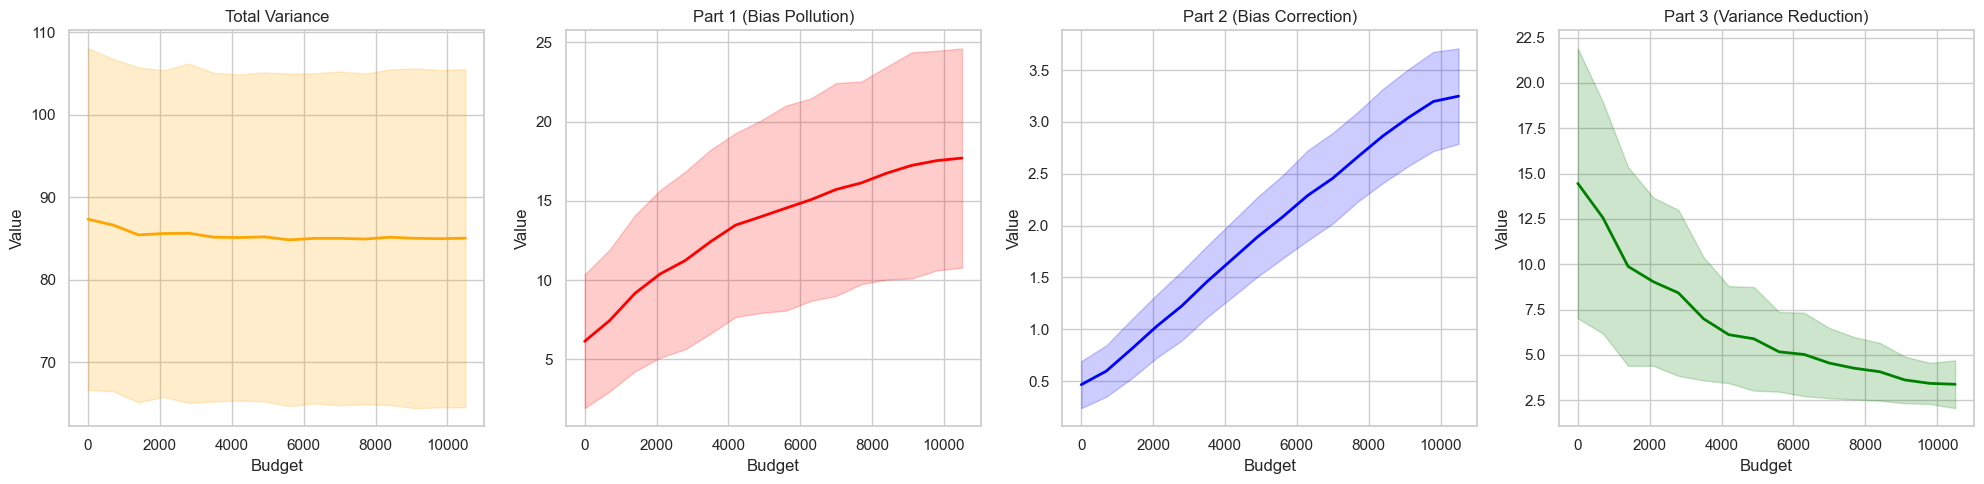

,Const_Term1,Const_Term2,Part1,Part2,Part3,Total_Variance
Budget,,,,,,
1,8.234441,58.956215,6.134011,0.465398,14.462485,87.321755
700,8.234441,58.956215,7.453369,0.596689,12.566200,86.613535
1400,8.234441,58.956215,9.159794,0.809143,9.882886,85.424193
2100,8.234441,58.956215,10.383715,1.028426,9.041992,85.587937
2800,8.234441,58.956215,11.234648,1.225407,8.423391,85.623288
3500,8.234441,58.956215,12.414581,1.459123,6.997086,85.143200
4200,8.234441,58.956215,13.465664,1.673789,6.120252,85.102783
4900,8.234441,58.956215,13.993202,1.889214,5.891794,85.186438
5600,8.234441,58.956215,14.538296,2.082268,5.174454,84.821138


In [124]:
NUM_ROLLS    = 100
SOURCE_IDX   = 2
budget_steps = np.linspace(1,
                           BASE_COST * COST_MULTIPLIERS[SOURCE_IDX] *
                           NUM_PATIENTS * 1.05,
                           16, dtype=int)

records = []
for roll in range(NUM_ROLLS):
    env = generate_synthetic_env(SEED + roll)
    for budget in budget_steps:
        if budget == 0:
            n_k_alloc = np.zeros_like(env['eps_k'], dtype=int)
        else:
            n_k_alloc = allocate_budget_randomly(env['n_f'], budget, COSTS,
                                                 source_idx=SOURCE_IDX)
        comps = get_variance_components(n_k_alloc, env)
        comps.update({'Budget': budget, 'Roll': roll})
        records.append(comps)
df_results = pd.DataFrame(records)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metrics = [
    ("Total_Variance", "Total Variance",            "orange"),
    ("Part1",          "Part 1 (Bias Pollution)",   "red"),
    ("Part2",          "Part 2 (Bias Correction)",  "blue"),
    ("Part3",          "Part 3 (Variance Reduction)","green"),
]
for i, (m, title, c) in enumerate(metrics):
    sns.lineplot(data=df_results, x="Budget", y=m, ax=axes[i],
                 color=c, errorbar='sd', linewidth=2)
    axes[i].set_title(title); axes[i].set_xlabel("Budget"); axes[i].set_ylabel("Value")
plt.tight_layout(); plt.show()

display(df_results.groupby("Budget").mean().drop(columns=["Roll"]))

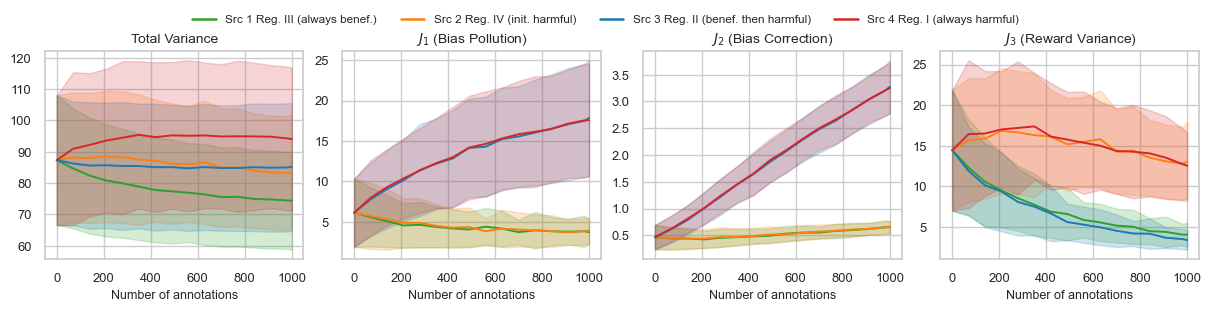

In [139]:
## Four Regimes Comparison
NUM_ROLLS = 100
N_STEPS   = 16

records = []
for source_idx in range(NUM_SOURCES):
    max_budget   = COSTS[source_idx] * NUM_PATIENTS * 1.05
    budget_steps = np.linspace(1, max_budget, N_STEPS, dtype=int)
    for roll in range(NUM_ROLLS):
        env = generate_synthetic_env(SEED + roll)
        for budget in budget_steps:
            n_k_alloc = allocate_budget_randomly(env['n_f'], budget, COSTS,
                                                 source_idx=source_idx)
            comps = get_variance_components(n_k_alloc, env)
            comps.update({'Num_Annotations': int(n_k_alloc.sum()),
                          'Source': source_idx + 1, 'Roll': roll})
            records.append(comps)
df_all = pd.DataFrame(records)

sns.set_theme(style='whitegrid', font_scale=0.85)
fig, axes = plt.subplots(1, 4, figsize=(12, 2.8), constrained_layout=True)
metrics = [
    ("Total_Variance", "Total Variance"),
    ("Part1",          r"$J_1$ (Bias Pollution)"),
    ("Part2",          r"$J_2$ (Bias Correction)"),
    ("Part3",          r"$J_3$ (Reward Variance)"),
]
regime_info = {
    1: ("Src 1 Reg. III (always benef.)",      "tab:green"),
    2: ("Src 2 Reg. IV (init. harmful)",       "tab:orange"),
    3: ("Src 3 Reg. II (benef. then harmful)", "tab:blue"),
    4: ("Src 4 Reg. I (always harmful)",       "tab:red"),
}
for i, (m, title) in enumerate(metrics):
    for k, (lbl, color) in regime_info.items():
        dfk = df_all[df_all['Source'] == k]
        sns.lineplot(data=dfk, x='Num_Annotations', y=m, ax=axes[i],
                     color=color, errorbar='sd', linewidth=1.4, legend=False)
    axes[i].set_title(title, fontsize=10)
    axes[i].set_xlabel("Number of annotations", fontsize=9)
    axes[i].set_ylabel("")

handles = [plt.Line2D([0], [0], color=c, lw=1.8) for _, c in regime_info.values()]
labels  = [lbl for lbl, _ in regime_info.values()]
fig.legend(handles, labels, loc='upper center',
           bbox_to_anchor=(0.5, 1.08), ncol=4, frameon=False, fontsize=8.5)
plt.savefig("four_regimes_combined.pdf", bbox_inches='tight')
plt.show()

## Optimization

In [126]:
## Run Optimization (Synthetic)
optimizer = BudgetOptimizer(env_syn, BUDGET, COSTS)

print("Starting Optimization (Synthetic)...")
n_k_opt, history_df = optimizer.optimize(max_mm_iter=15)

baseline_obj = history_df.iloc[0]['obj']
final_obj    = history_df.iloc[-1]['obj']
print(f"\nBaseline Variance:  {baseline_obj:.6f}")
print(f"Optimized Variance: {final_obj:.6f}")
print(f"Reduction: {(baseline_obj - final_obj) / baseline_obj * 100:.2f}%")

Starting Optimization (Synthetic)...
Iter  | Objective    | Cost       | Total N    | n_0      | n_1      | n_2      | n_3      | Lambda    
-------------------------------------------------------------------------------------------------------
-1    | 84.234418    | 0.0        | 0          | 0        | 0        | 0        | 0        | 0.0000    
0     | 67.695478    | 7010.0     | 510        | 293      | 168      | 29       | 20       | 0.0001    
1     | 67.484800    | 7193.0     | 614        | 258      | 228      | 85       | 43       | 0.0001    
2     | 67.373299    | 7127.0     | 678        | 233      | 240      | 118      | 87       | 0.0001    
3     | 67.318283    | 7009.0     | 707        | 214      | 217      | 152      | 124      | 0.0001    
4     | 67.318283    | 7009.0     | 707        | 214      | 217      | 152      | 124      | 0.0001    
Converged.

Baseline Variance:  84.234418
Optimized Variance: 67.318283
Reduction: 20.08%


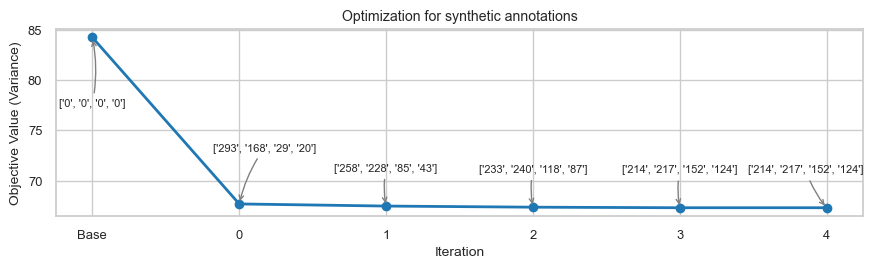

In [154]:
## Plot Optimization Trajectory
plt.figure(figsize=(9, 2.8))
plot_iters = history_df['iter'].tolist()
plot_objs  = history_df['obj'].tolist()

plt.plot(plot_iters, plot_objs, marker='o', linestyle='-', color='tab:blue',
         linewidth=2, label='Total Variance', zorder=1)

n_cols = [c for c in history_df.columns if c.startswith('n_')]
indices_to_label = sorted(set(range(min(7, len(plot_iters)))))

for idx in indices_to_label:
    it, obj = plot_iters[idx], plot_objs[idx]
    n_values = history_df.iloc[idx][n_cols].tolist()
    n_str = [str(int(v)) if v == int(v) else f"{v:.1f}" for v in n_values]
    if idx == indices_to_label[-1]:
        offset = (-15, 25)
    elif idx == indices_to_label[0]:
        offset = (0, -50)
    elif idx == indices_to_label[1]:
        offset = (18, 38)
    else:
        offset = (0, 25)
    plt.annotate(f"{n_str}", xy=(it, obj), xytext=offset,
                 textcoords='offset points', ha='center', fontsize=8,
                 arrowprops=dict(arrowstyle='->',
                                 connectionstyle="arc3,rad=0.1", color='gray'))

plt.xlabel('Iteration', fontsize=10)
plt.ylabel('Objective Value (Variance)', fontsize=10)
plt.title('Optimization for synthetic annotations')
plt.xticks(plot_iters, ['Base' if i == -1 else str(i) for i in plot_iters])
plt.grid(True); plt.tight_layout()
plt.savefig("optimization_syn.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Combination Comparison

In [128]:
all_ids = list(range(NUM_SOURCES))
combos  = [c for r in range(1, NUM_SOURCES + 1)
             for c in combinations(all_ids, r)]
# Use smaller subsets as warm-starts
combos_sorted = sorted(combos, key=lambda c: (len(c), c))

baseline_no_anno = calc_objective(
    np.zeros((NUM_SOURCES, NUM_STATES, NUM_ACTIONS), dtype=int), env_syn)

results   = []
solutions = {}

for combo in combos_sorted:
    label = '{' + ','.join(str(i + 1) for i in combo) + '}'

    # ---- pick the best warm-start among already-solved subsets
    best_init, best_init_J = None, np.inf
    for sub_t, (sub_n, sub_J) in solutions.items():
        if set(sub_t).issubset(set(combo)) and sub_J < best_init_J:
            best_init_J, best_init = sub_J, sub_n

    if len(combo) == 1:
        src = combo[0]
        n_opt = allocate_budget_randomly(env_syn['n_f'], BUDGET, COSTS,
                                         source_idx=src)
        obj   = calc_objective(n_opt, env_syn)
    else:
        print(f"Optimising combo {label} ...")
        opt = BudgetOptimizer(env_syn, BUDGET, COSTS, active_sources=list(combo))
        n_opt, hist = opt.optimize(max_mm_iter=10,
                                   n_init=best_init, verbose=False)
        obj = hist.iloc[-1]['obj']

    solutions[tuple(combo)] = (n_opt, obj)
    results.append({'label': label,
                    'num_sources': len(combo),
                    'objective': obj})

df_combo = (pd.DataFrame(results)
              .sort_values(['num_sources', 'objective'])
              .reset_index(drop=True))
print(df_combo)

Optimising combo {1,2} ...
Optimising combo {1,3} ...
Optimising combo {1,4} ...
Optimising combo {2,3} ...
Optimising combo {2,4} ...
Optimising combo {3,4} ...
Optimising combo {1,2,3} ...
Optimising combo {1,2,4} ...
Optimising combo {1,3,4} ...
Optimising combo {2,3,4} ...
Optimising combo {1,2,3,4} ...
        label  num_sources  objective
0         {1}            1  70.108179
1         {2}            1  77.490568
2         {3}            1  77.552592
3         {4}            1  84.914348
4       {1,3}            2  67.117589
5       {1,4}            2  67.373706
6       {1,2}            2  67.380028
7       {2,3}            2  68.449489
8       {2,4}            2  69.526620
9       {3,4}            2  72.170606
10    {1,2,3}            3  67.096559
11    {1,3,4}            3  67.117589
12    {1,2,4}            3  67.373706
13    {2,3,4}            3  68.448930
14  {1,2,3,4}            4  66.895146


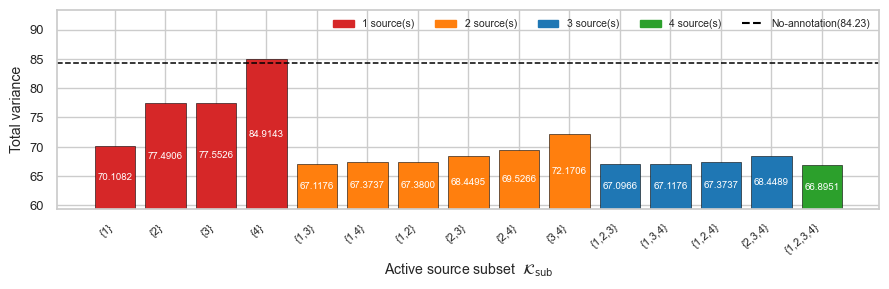

In [151]:
sns.set_theme(style='whitegrid', font_scale=0.85)
fig, ax = plt.subplots(figsize=(9, 3.0))
colour_by_size = {1: '#d62728', 2: '#ff7f0e', 3: '#1f77b4', 4: '#2ca02c'}
colours = [colour_by_size[n] for n in df_combo['num_sources']]

x = np.arange(len(df_combo))
bars = ax.bar(x, df_combo['objective'], color=colours,
              edgecolor='black', linewidth=0.4)
ax.bar_label(bars, fmt='%.4f', label_type='center', color='white', fontsize=7)
ax.axhline(baseline_no_anno, color='black', linestyle='--', linewidth=1.1)

ax.set_xticks(x)
ax.set_xticklabels(df_combo['label'], rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Total variance')
ax.set_xlabel(r'Active source subset  $\mathcal{K}_{\mathrm{sub}}$')

legend_handles = [plt.Rectangle((0, 0), 1, 1, color=colour_by_size[k],
                                label=f'{k} source(s)') for k in [1, 2, 3, 4]]
legend_handles.append(plt.Line2D([0], [0], color='black', linestyle='--',
                                 label=f'No-annotation({baseline_no_anno:.2f})'))
ax.legend(handles=legend_handles, loc='upper right',
          fontsize=7.5, ncol=5, frameon=False)
ax.set_ylim(df_combo['objective'].max()*0.7, top=df_combo['objective'].max()*1.1)
plt.tight_layout()
plt.savefig("source_combinations.pdf", dpi=150, bbox_inches='tight')
plt.show()

# Real LLMs Annotations in ASSIT dataset

* **Gemini Flash 2.5**
    * Price per 1M tokens: `$0.30` (Input), `$2.50` (Output)
    * Prompt tokens: `4,776,600`, Completion tokens: `711,597`
    * Total Estimated Cost for 20 replications: **`$1.14`**

* **GPT-4o-mini**
    * Price per 1M tokens: `$0.15` (Input), `$0.60` (Output)
    * Prompt tokens: `4,446,160`, Completion tokens: `411,973`
    * Total Estimated Cost for 20 replications: **`$0.4763`**

* **GPT-o3-mini**
    * Price per 1M tokens: `$1.1` (Input), `$4.4` (Output)
    * Prompt tokens: `4,446,160`, Completion tokens: `7,358,757`
    * Total Estimated Cost for 20 replications: **`$37.26`**

* **Claude-haiku-4.5**
    * Price per 1M tokens: `$1` (Input), `$5` (Output)
    * Prompt tokens: `6,047,398`, Completion tokens: `818,318`
    * Total Estimated Cost 20 replications: **`$8.11`**

## Load Data

In [130]:
# Real-LLM ASSIST Experiments ## Load LLM Annotations
LLM_FILES = {
    'Gemini': "ASSIST_annotations_gemini.npz",
    'Claude': "ASSIST_annotations_claudehaiku.npz",
    'GPT4o' : "ASSIST_annotations_gpt4omini.npz",
    # 'GPTo3' : "ASSIST_annotations_gpto3mini.npz",
}
LLM_ANN = {}
for name, path in LLM_FILES.items():
    out = np.load(path)
    LLM_ANN[name] = {'mu': out['ann_mu'], 'var': out['ann_var']}
    print(f"Loaded {name}: mu shape={out['ann_mu'].shape}")

Loaded Gemini: mu shape=(100, 10)
Loaded Claude: mu shape=(100, 10)
Loaded GPT4o: mu shape=(100, 10)


## Build Environment

In [131]:
SEED_BKT = 20260504
data_path = "ASSIST_params_irt_time.npz"
data = np.load(data_path)

NUM_STATES_BKT  = 100
NUM_ACTIONS_BKT = 10
NUM_SOURCES_BKT = len(LLM_ANN)
NUM_PATIENTS_BKT = 6000

# True dynamics from the IRT-fitted file
mu_r_bkt        = data['mu_r'][:NUM_STATES_BKT, :NUM_ACTIONS_BKT]
sigma_r_sq_bkt  = data['sigma_r_sq'][:NUM_STATES_BKT, :NUM_ACTIONS_BKT]
pi_b_bkt        = data['pi_b'][:NUM_STATES_BKT, :NUM_ACTIONS_BKT]
pi_e_bkt        = data['pi_e'][:NUM_STATES_BKT, :NUM_ACTIONS_BKT]
d0_bkt          = data['d0'][:NUM_STATES_BKT]
d0_bkt          = d0_bkt / d0_bkt.sum()
pi_b_bkt        = pi_b_bkt / pi_b_bkt.sum(axis=1, keepdims=True)
pi_e_bkt        = pi_e_bkt / pi_e_bkt.sum(axis=1, keepdims=True)

COSTS_BKT  = np.array([1.14 / 20000, 8.11 / 20000, 0.48 / 20000])
BUDGET_BKT = 0.5

LLM_ORDER = ['Gemini', 'Claude', 'GPT4o']           # column order

def generate_bkt_env(seed):
    rng = np.random.default_rng(seed)

    eps_k_all    = np.zeros((NUM_SOURCES_BKT, NUM_STATES_BKT, NUM_ACTIONS_BKT))
    var_k_sa_all = np.zeros((NUM_SOURCES_BKT, NUM_STATES_BKT, NUM_ACTIONS_BKT))
    for i, name in enumerate(LLM_ORDER):
        eps_k_all[i]    = LLM_ANN[name]['mu']  - mu_r_bkt
        var_k_sa_all[i] = LLM_ANN[name]['var']
    delta_g_k = var_k_sa_all - sigma_r_sq_bkt[None, :, :]

    state_counts = rng.multinomial(NUM_PATIENTS_BKT, d0_bkt)
    n_f = np.zeros((NUM_STATES_BKT, NUM_ACTIONS_BKT), dtype=int)
    for s in range(NUM_STATES_BKT):
        if state_counts[s] > 0:
            n_f[s] = rng.multinomial(state_counts[s], pi_b_bkt[s])

    env = {
        "n_f": n_f, "pi_e": pi_e_bkt, "pi_b": pi_b_bkt, "d0": d0_bkt,
        "mu_r": mu_r_bkt, "sigma_r_sq": sigma_r_sq_bkt,
        "eps_k": eps_k_all, "delta_g_k": delta_g_k,
    }
    return _build_env_constants(env)

In [132]:
env_bkt = generate_bkt_env(SEED_BKT)

print(f"BKT Environment Initialized.")
print(f"Sparsity: {np.mean(env_bkt['n_f'] == 0) * 100:.2f}%")
print(f"Constant Term 1: {env_bkt['term1_const']:.6f}")
print(f"Constant Term 2: {env_bkt['term2_const']:.6f}")

BKT Environment Initialized.
Sparsity: 17.50%
Constant Term 1: 16.401207
Constant Term 2: 61.300636


## Four Regimes & Variance Decompostion

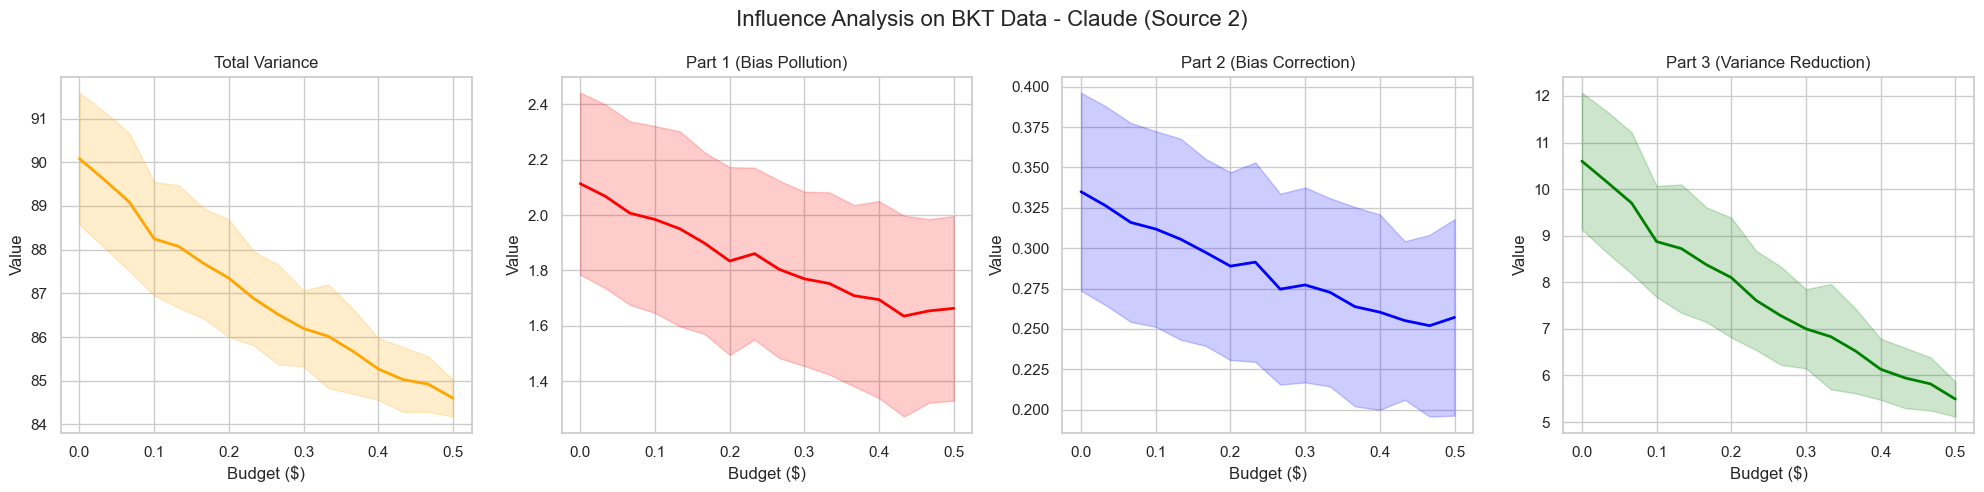

,Num_Annotations,Total_Variance,Part1,Part2,Part3
Budget ($),,,,,
0.000000,0.0,90.081269,2.113652,0.334965,10.600739
0.033333,82.0,89.599915,2.068570,0.326164,10.155667
0.066667,164.0,89.092614,2.007029,0.315914,9.699656
0.100000,246.0,88.248442,1.984423,0.311851,8.874027
0.133333,328.0,88.069400,1.950638,0.305537,8.722456
0.166667,411.0,87.680254,1.898180,0.297399,8.377629
0.200000,493.0,87.348878,1.834173,0.288856,8.101718
0.233333,575.0,86.882309,1.860827,0.291352,7.610990
0.266667,657.0,86.510455,1.803685,0.274597,7.279524


In [133]:
## Variance Decomposition - Single LLM vs Budget
TEST_SOURCE_IDX = 1                                   # 0:Gemini 1:Claude 2:GPT4o
NUM_ROLLS_BKT   = 50

budget_steps_bkt = np.linspace(0, BUDGET_BKT, 16)
records = []
for roll in range(NUM_ROLLS_BKT):
    env = generate_bkt_env(SEED_BKT + roll)
    for budget in budget_steps_bkt:
        if budget == 0:
            n_k_alloc = np.zeros_like(env['eps_k'], dtype=int)
        else:
            n_k_alloc = allocate_budget_randomly(env['n_f'], budget, COSTS_BKT,
                                                 source_idx=TEST_SOURCE_IDX)
        comps = get_variance_components(n_k_alloc, env)
        comps.update({'Budget ($)': budget,
                      'Num_Annotations': int(n_k_alloc.sum()),
                      'Roll': roll})
        records.append(comps)
df_results_bkt = pd.DataFrame(records)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metrics = [
    ("Total_Variance", "Total Variance",            "orange"),
    ("Part1",          "Part 1 (Bias Pollution)",   "red"),
    ("Part2",          "Part 2 (Bias Correction)",  "blue"),
    ("Part3",          "Part 3 (Variance Reduction)","green"),
]
for i, (m, title, c) in enumerate(metrics):
    sns.lineplot(data=df_results_bkt, x="Budget ($)", y=m, ax=axes[i],
                 color=c, errorbar='sd', linewidth=2)
    axes[i].set_title(title); axes[i].set_xlabel("Budget ($)"); axes[i].set_ylabel("Value")
plt.suptitle(f"Influence Analysis on BKT Data - "
             f"{LLM_ORDER[TEST_SOURCE_IDX]} (Source {TEST_SOURCE_IDX+1})",
             fontsize=16)
plt.tight_layout(); plt.show()

display(df_results_bkt.groupby("Budget ($)").mean()
        .drop(columns=["Roll"])
        [['Num_Annotations', 'Total_Variance', 'Part1', 'Part2', 'Part3']])

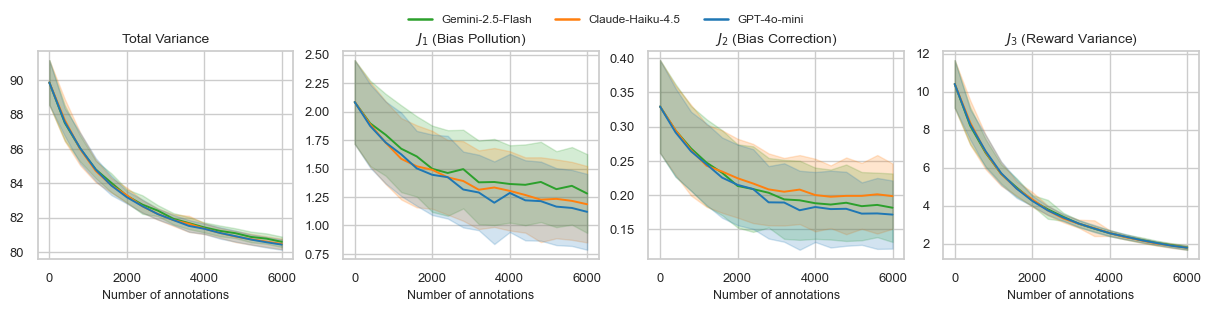

In [152]:
NUM_ROLLS = 100
N_STEPS   = 16
n_steps_grid = np.linspace(0, NUM_PATIENTS_BKT, N_STEPS, dtype=int)

records = []
for source_idx in range(NUM_SOURCES_BKT):
    for roll in range(NUM_ROLLS):
        env = generate_bkt_env(SEED_BKT + roll)
        for n_target in n_steps_grid:
            budget = n_target * COSTS_BKT[source_idx] * 1.001
            n_k_alloc = allocate_budget_randomly(env['n_f'], budget, COSTS_BKT,
                                                 source_idx=source_idx)
            comps = get_variance_components(n_k_alloc, env)
            comps.update({'Num_Annotations': int(n_k_alloc.sum()),
                          'Source': source_idx + 1, 'Roll': roll})
            records.append(comps)
df_all_bkt = pd.DataFrame(records)

sns.set_theme(style='whitegrid', font_scale=0.85)
fig, axes = plt.subplots(1, 4, figsize=(12, 2.8), constrained_layout=True)
metrics = [
    ("Total_Variance", "Total Variance"),
    ("Part1",          r"$J_1$ (Bias Pollution)"),
    ("Part2",          r"$J_2$ (Bias Correction)"),
    ("Part3",          r"$J_3$ (Reward Variance)"),
]
LLM_info = {
    1: ("Gemini-2.5-Flash", "tab:green"),
    2: ("Claude-Haiku-4.5", "tab:orange"),
    3: ("GPT-4o-mini",      "tab:blue"),
}
for i, (m, title) in enumerate(metrics):
    for k, (lbl, color) in LLM_info.items():
        dfk = df_all_bkt[df_all_bkt['Source'] == k]
        if dfk.empty: continue
        sns.lineplot(data=dfk, x='Num_Annotations', y=m, ax=axes[i],
                     color=color, errorbar='sd', linewidth=1.4, legend=False)
    axes[i].set_title(title, fontsize=10)
    axes[i].set_xlabel("Number of annotations", fontsize=9)
    axes[i].set_ylabel("")

handles = [plt.Line2D([0], [0], color=c, lw=1.8) for _, c in LLM_info.values()]
labels  = [lbl for lbl, _ in LLM_info.values()]
fig.legend(handles, labels, loc='upper center',
           bbox_to_anchor=(0.5, 1.08), ncol=len(labels),
           frameon=False, fontsize=8.5)
plt.savefig("LLMs_decomposition.pdf", bbox_inches='tight', dpi=150)
plt.show()

## Optimization

In [135]:
## Run BKT Optimization
optimizer_bkt = BudgetOptimizer(env_bkt, BUDGET_BKT, COSTS_BKT)

print("Starting BKT Education Optimization...")
n_k_opt_bkt, history_df_bkt = optimizer_bkt.optimize(max_mm_iter=15)

print(f"\nReduction: "
      f"{(history_df_bkt.iloc[0]['obj'] - history_df_bkt.iloc[-1]['obj']) / history_df_bkt.iloc[0]['obj'] * 100:.2f}%")

Starting BKT Education Optimization...
Iter  | Objective    | Cost       | Total N    | n_0      | n_1      | n_2      | Lambda    
--------------------------------------------------------------------------------------------
-1    | 88.607578    | 0.0        | 0          | 0        | 0        | 0        | 0.0000    
0     | 79.097320    | 0.5        | 6000       | 2180     | 744      | 3076     | 0.0292    
1     | 79.065183    | 0.5        | 6000       | 2237     | 739      | 3024     | 0.0203    
2     | 79.062847    | 0.5        | 6000       | 2278     | 734      | 2988     | 0.0214    
3     | 79.061995    | 0.5        | 6000       | 2263     | 737      | 3000     | 0.0225    
4     | 79.061709    | 0.5        | 6000       | 2246     | 737      | 3017     | 0.0236    
5     | 79.061651    | 0.5        | 6000       | 2247     | 737      | 3016     | 0.0239    
Converged.

Reduction: 10.77%


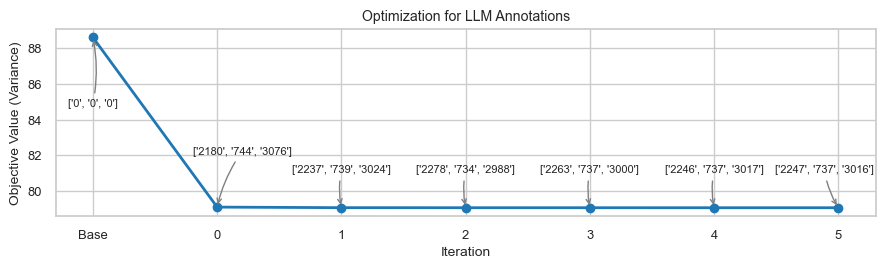

In [153]:
plt.figure(figsize=(9, 2.8))
plot_iters = history_df_bkt['iter'].tolist()
plot_objs  = history_df_bkt['obj'].tolist()

plt.plot(plot_iters, plot_objs, marker='o', linestyle='-', color='tab:blue',
         linewidth=2, label='Total Variance', zorder=1)

n_cols = [c for c in history_df_bkt.columns if c.startswith('n_')]
indices_to_label = sorted(set(range(min(7, len(plot_iters)))))

for idx in indices_to_label:
    it, obj = plot_iters[idx], plot_objs[idx]
    n_values = history_df_bkt.iloc[idx][n_cols].tolist()
    n_str = [str(int(v)) if v == int(v) else f"{v:.1f}" for v in n_values]
    if idx == indices_to_label[-1]:
        offset = (-10, 25)
    elif idx == indices_to_label[0]:
        offset = (0, -50)
    elif idx == indices_to_label[1]:
        offset = (18, 38)
    else:
        offset = (0, 25)
    plt.annotate(f"{n_str}", xy=(it, obj), xytext=offset,
                 textcoords='offset points', ha='center', fontsize=8,
                 arrowprops=dict(arrowstyle='->',
                                 connectionstyle="arc3,rad=0.1", color='gray'))

plt.xlabel('Iteration', fontsize=10)
plt.ylabel('Objective Value (Variance)', fontsize=10)
plt.title('Optimization for LLM Annotations')
plt.xticks(plot_iters, ['Base' if i == -1 else str(i) for i in plot_iters])
plt.grid(True); plt.tight_layout()
plt.savefig("optimization_llm.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Combination Comparison

In [137]:
all_ids_bkt = list(range(NUM_SOURCES_BKT))
combos_bkt  = [c for r in range(1, NUM_SOURCES_BKT + 1)
                 for c in combinations(all_ids_bkt, r)]
combos_bkt_sorted = sorted(combos_bkt, key=lambda c: (len(c), c))
model_names = {0: 'Gemini', 1: 'Claude', 2: 'GPT'}

baseline_no_anno_bkt = calc_objective(
    np.zeros((NUM_SOURCES_BKT, NUM_STATES_BKT, NUM_ACTIONS_BKT), dtype=int),
    env_bkt)

results_bkt = []
solutions_bkt = {}

for combo in combos_bkt_sorted:
    label = '{' + ', '.join(model_names[i] for i in combo) + '}'

    best_init, best_init_J = None, np.inf
    for sub_t, (sub_n, sub_J) in solutions_bkt.items():
        if set(sub_t).issubset(set(combo)) and sub_J < best_init_J:
            best_init_J, best_init = sub_J, sub_n

    if len(combo) == 1:
        src = combo[0]
        n_opt = allocate_budget_randomly(env_bkt['n_f'], BUDGET_BKT,
                                         COSTS_BKT, source_idx=src)
        obj   = calc_objective(n_opt, env_bkt)
    else:
        print(f"Optimising combo {label} ...")
        opt = BudgetOptimizer(env_bkt, BUDGET_BKT, COSTS_BKT,
                              active_sources=list(combo))
        n_opt, hist = opt.optimize(max_mm_iter=10,
                                   n_init=best_init, verbose=False)
        obj = hist.iloc[-1]['obj']

    if best_init is not None and best_init_J < obj:
        n_opt, obj = best_init, best_init_J

    solutions_bkt[tuple(combo)] = (n_opt, obj)
    results_bkt.append({'label': label,
                        'num_sources': len(combo),
                        'objective': obj})

df_combo_bkt = (pd.DataFrame(results_bkt)
                  .sort_values(['num_sources', 'objective'])
                  .reset_index(drop=True))
display(df_combo_bkt)

Optimising combo {Gemini, Claude} ...
Optimising combo {Gemini, GPT} ...
Optimising combo {Claude, GPT} ...
Optimising combo {Gemini, Claude, GPT} ...


,label,num_sources,objective
0,{GPT},1,80.762365
1,{Gemini},1,81.014049
2,{Claude},1,84.580960
3,"{Gemini, GPT}",2,79.145300
4,"{Gemini, Claude}",2,79.156936
5,"{Claude, GPT}",2,79.158234
6,"{Gemini, Claude, GPT}",3,79.061578


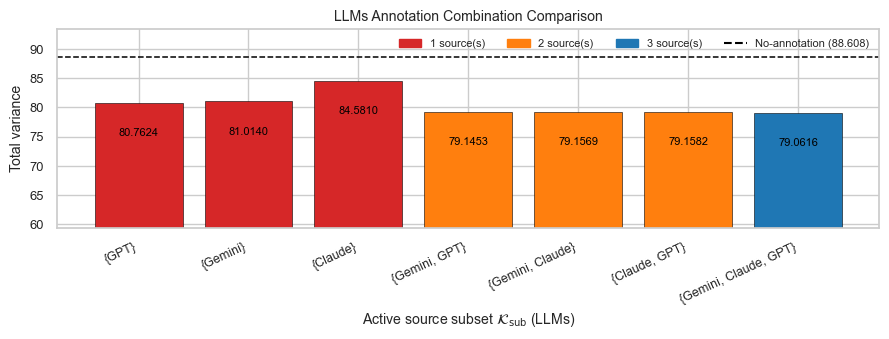

In [156]:
sns.set_theme(style='whitegrid', font_scale=0.85)
fig, ax = plt.subplots(figsize=(9, 3.5))

colour_by_size = {1: '#d62728', 2: '#ff7f0e', 3: '#1f77b4'}
colours = [colour_by_size[n] for n in df_combo_bkt['num_sources']]
x = np.arange(len(df_combo_bkt))

bars = ax.bar(x, df_combo_bkt['objective'], color=colours,
              edgecolor='black', linewidth=0.4)
ax.bar_label(bars, fmt='%.4f', label_type='edge', color='black',
             fontsize=8, padding=-25)
ax.axhline(baseline_no_anno_bkt, color='black', linestyle='--', linewidth=1.1)

ax.set_xticks(x)
ax.set_xticklabels(df_combo_bkt['label'], rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Total variance')
ax.set_xlabel(r'Active source subset $\mathcal{K}_{\mathrm{sub}}$ (LLMs)')
ax.set_ylim(bottom=0,
            top=max(df_combo_bkt['objective'].max() * 1.5,
                    baseline_no_anno_bkt) * 1.1)

legend_handles = [plt.Rectangle((0, 0), 1, 1, color=colour_by_size[k],
                                label=f'{k} source(s)') for k in [1, 2, 3]]
legend_handles.append(plt.Line2D([0], [0], color='black', linestyle='--',
                                 label=f'No-annotation ({baseline_no_anno_bkt:.3f})'))
ax.legend(handles=legend_handles, loc='upper right',
          fontsize=8, ncol=4, frameon=False)
ax.set_ylim(df_combo['objective'].max()*0.7, top=df_combo['objective'].max()*1.1)
plt.title("LLMs Annotation Combination Comparison")
plt.tight_layout()
plt.savefig("llm_source_combinations.pdf", dpi=300, bbox_inches='tight')
plt.show()